In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# This formatter will make y-axis show real numbers like $25,000,000
# instead of scientific notation like 2.5e7
money_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
print('Ready!')

Ready!


In [ ]:
# Cell 2 — Load the dataset
df = pd.read_excel('finance_transactions_dataset.xlsx')
# Quick check: how many rows and columns?
print(df.shape) # e.g. (1000, 14)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [ ]:
hi df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [ ]:
df.info

<bound method DataFrame.info of     Transaction_ID      Company      Sector Department Transaction_Type  \
0          TXN1001  GreenEnergy      Energy  Marketing   Loan Repayment   
1          TXN1002    LogiTrans   Logistics         IT   Loan Repayment   
2          TXN1003     EduGroup   Education      Sales       Investment   
3          TXN1004   HealthPlus  Healthcare      Sales          Revenue   
4          TXN1005     EduGroup   Education    Finance   Loan Repayment   
..             ...          ...         ...        ...              ...   
995        TXN1996     MediaMax       Media        NaN          Revenue   
996        TXN1997   HealthPlus  Healthcare  Marketing          Revenue   
997        TXN1998     TechCorp  Technology         IT   Loan Repayment   
998        TXN1999     MediaMax       Media         IT   Loan Repayment   
999        TXN2000    RetailHub      Retail      Sales       Investment   

    Category     Amount  Tax_Rate  Tax_Amount  Net_Amount Currency  \
0        NaN  104037.35      0.09     9363.36    94673.99      USD   
1        NaN  431438.64      0.10    43143.86   388294.78      USD   
2        NaN  494837.13      0.18    89070.68   405766.45      GBP   
3        NaN   59347.25      0.09     5341.25    54006.00      USD   
4        NaN  132500.40      0.15    19875.06   112625.34      GBP   
..       ...        ...       ...         ...         ...      ...   
995      NaN  131928.04      0.14    18469.93   113458.11      USD   
996      NaN  395637.83      0.28   110778.59   284859.24      GBP   
997      NaN  404246.71      0.22    88934.28   315312.43      USD   
998      NaN        NaN      0.06     1420.61    22256.26      USD   
999      NaN   65608.33      0.06     3936.50    61671.83      NGN   

    Transaction_Date Approval_Status    Analyst  
0         2022-05-24         Pending  Analyst_B  
1         2023-08-04         Pending  Analyst_D  
2         2023-08-05        Rejected  Analyst_B  
3         2024-11-01         Pending  Analyst_A  
4         2021-09-16        Approved  Analyst_C  
..               ...             ...        ...  
995       2024-07-27        Approved  Analyst_B  
996       2024-03-31        Approved  Analyst_C  
997       2021-06-03        Approved  Analyst_C  
998       2022-03-24         Pending  Analyst_C  
999       2024-10-27         Pending  Analyst_A  

[1000 rows x 14 columns]>

In [ ]:
df.describe().round()

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.0,1000.0,1000.0,960.0
mean,248309.0,0.0,44197.0,203860.0
std,145329.0,0.0,33448.0,120727.0
min,5133.0,0.0,355.0,3644.0
25%,115322.0,0.0,16896.0,94843.0
50%,250121.0,0.0,35780.0,200693.0
75%,375654.0,0.0,66364.0,308533.0
max,499772.0,0.0,148758.0,454366.0


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Company,44
Sector,0
Department,54
Transaction_Type,0
Category,789
Amount,39
Tax_Rate,0
Tax_Amount,0
Net_Amount,40


In [ ]:
# Cell 4a — Remove rows where essential columns are empty
df.dropna(subset=['Amount', 'Net_Amount', 'Transaction_Date',
'Approval_Status'],
inplace=True)
print('Rows remaining:', len(df))

Rows remaining: 845


In [ ]:
# Cell 4b — Fill gaps in text columns
df['Company'] = df['Company'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unknown')
df['Analyst'] = df['Analyst'].fillna('Unknown')
df['Category'] = df['Category'].fillna('N/A')
# Cell 4c — Turn text dates into proper dates, then extract Year and Month
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'],
errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)
print('Sample dates:')
print(df[['Transaction_Date', 'Year', 'Month']].head(3))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [ ]:
# Cell 4d
df.drop_duplicates(inplace=True)
print('Final row count:', len(df))

Final row count: 845


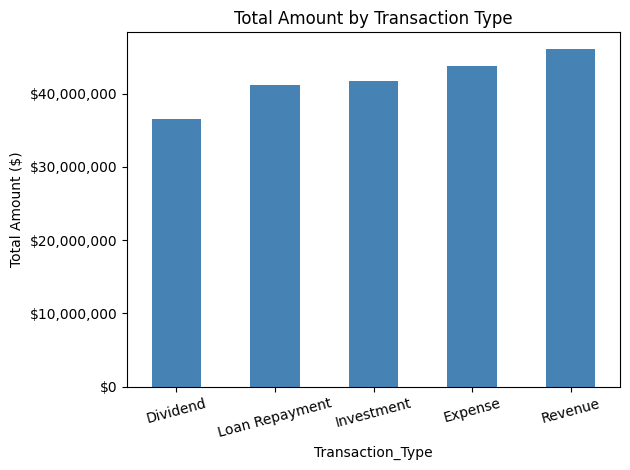

In [ ]:
# Cell 5a — Bar chart
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(kind='bar',
color='steelblue')
plt.title('Total Amount by Transaction Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not
2.5e7
plt.tight_layout()
plt.show()

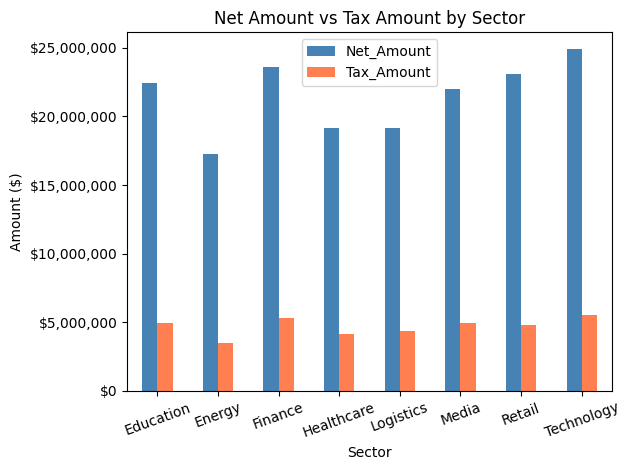

In [ ]:
# Cell 5b — Grouped bar chart
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar',
color=['steelblue', 'coral'])
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not
2.5e7
plt.tight_layout()
plt.show()

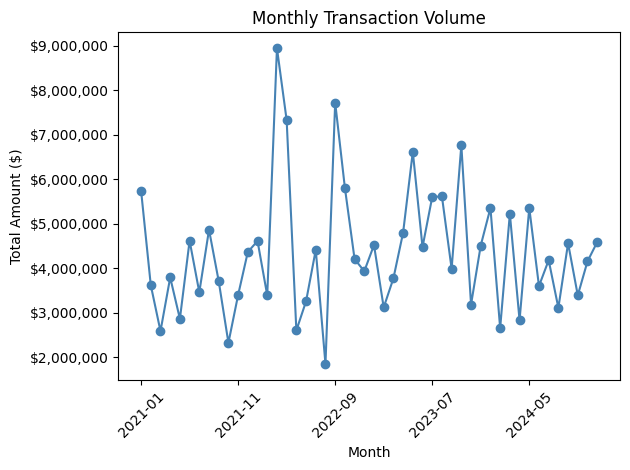

In [ ]:
# Cell 5c — Line chart
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o',
color='steelblue')
plt.title('Monthly Transaction Volume')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not
2.5e7
plt.tight_layout()
plt.show()

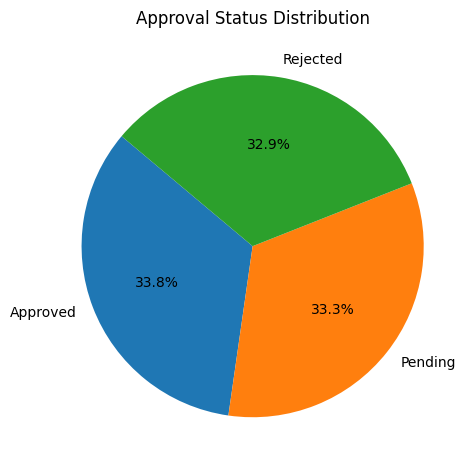

In [ ]:
# Cell 5d — Pie chart
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%',
startangle=140)
plt.title('Approval Status Distribution')
plt.ylabel('') # hides the default y-axis label on pie charts
plt.tight_layout()
plt.show()

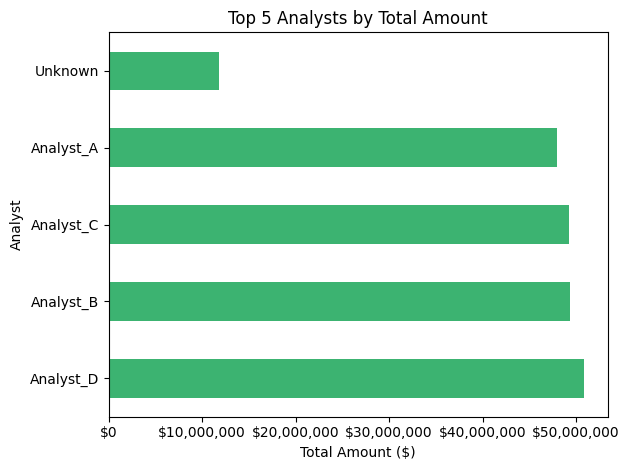

In [ ]:
# Cell 5e — Horizontal bar chart
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh',
color='mediumseagreen')
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt) # x-axis for horizontal bars
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6 — Summary
print('=' * 46)
print(' FINANCE DATASET SUMMARY')
print('=' * 46)
print(f"Transactions: {len(df):,}")
print(f"Total Amount: ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid: ${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount: ${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate: {df['Tax_Rate'].mean()*100:.1f}%")
print(f"Approval Rate: {(df['Approval_Status']=='Approved').mean()*100:.1f}%")
print(f"Top Sector: {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst: {df.groupby('Analyst')['Amount'].sum().idxmax()}")

 FINANCE DATASET SUMMARY
Transactions: 845
Total Amount: $209,284,457
Total Tax Paid: $37,622,745
Total Net Amount: $171,661,713
Avg Tax Rate: 17.9%
Approval Rate: 33.8%
Top Sector: Technology
Top Analyst: Analyst_D
